In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil di-import")

Library berhasil di-import


In [3]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy scikit-learn imbalanced-learn xgboost shap mlflow fastapi uvicorn pydantic joblib python-multipart

  Using cached mlflow-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.11.1-py3-none-any.whl.metadata (49 kB)
Using cached mlflow-3.11.1-py3-none-any.whl (10.5 MB)
Using cached mlflow_skinny-3.11.1-py3-none-any.whl (3.2 MB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\agung\\OneDrive\\Desktop\\fraud-detection-mlops\\venv\\Lib\\site-packages\\mlflow\\utils\\workspace_context.py'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

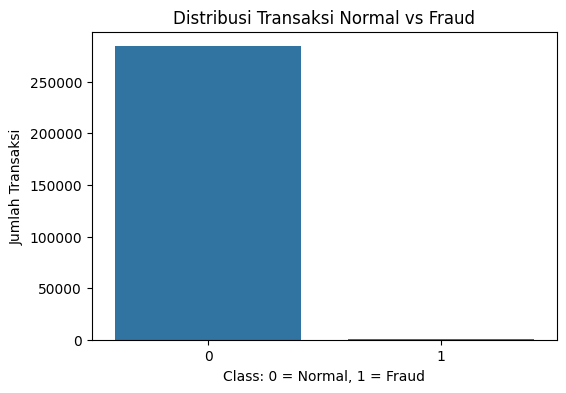

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Distribusi Transaksi Normal vs Fraud")
plt.xlabel("Class: 0 = Normal, 1 = Fraud")
plt.ylabel("Jumlah Transaksi")
plt.show()

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1081)

In [13]:
df.to_csv("../data/processed/fraud_clean.csv", index=False)

print("fraud_clean.csv berhasil disimpan")

fraud_clean.csv berhasil disimpan


In [14]:
class_count = df["Class"].value_counts()
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_count)
print(class_percentage)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


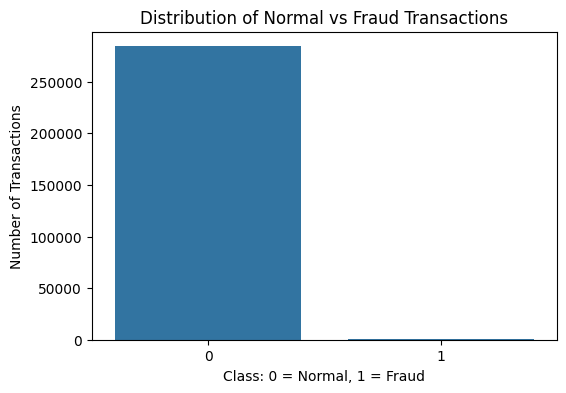

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Distribution of Normal vs Fraud Transactions")
plt.xlabel("Class: 0 = Normal, 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

In [16]:
fraud_rate = df["Class"].mean() * 100
print(f"Fraud Rate: {fraud_rate:.4f}%")

Fraud Rate: 0.1727%


In [17]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


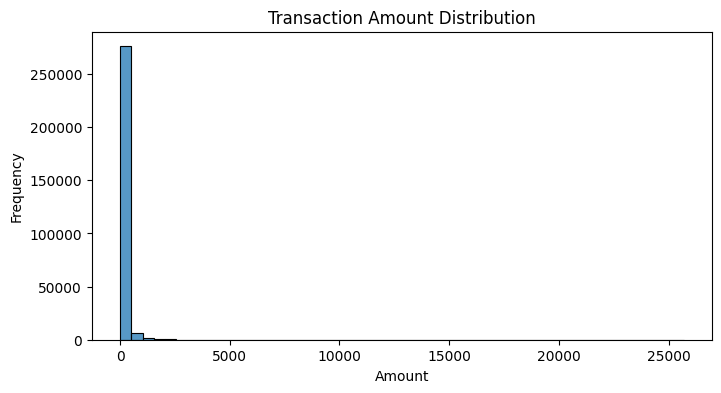

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

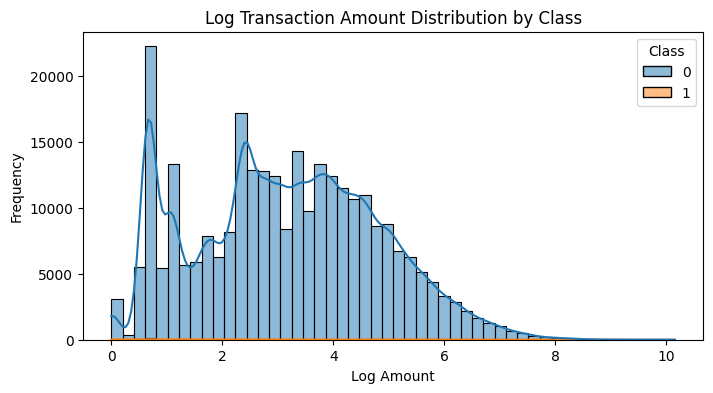

In [19]:
df["Amount_Log"] = np.log1p(df["Amount"])

plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Amount_Log", hue="Class", bins=50, kde=True)
plt.title("Log Transaction Amount Distribution by Class")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

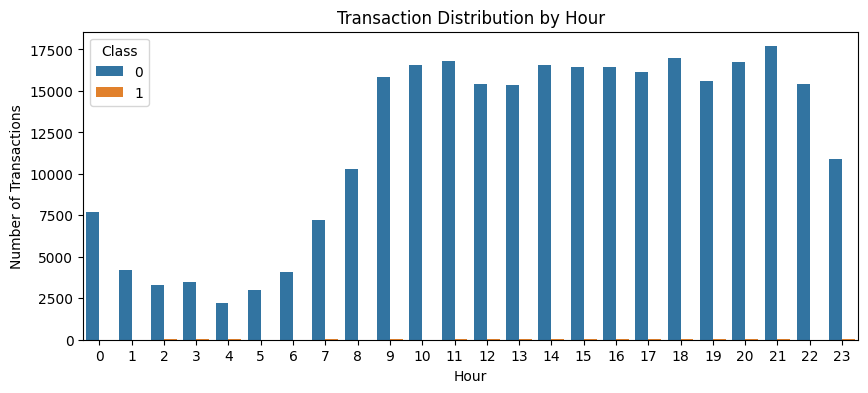

In [20]:
df["Hour"] = (df["Time"] / 3600) % 24
df["Hour"] = df["Hour"].astype(int)

plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Hour", hue="Class")
plt.title("Transaction Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()

In [21]:
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target

Class         1.000000
V11           0.154876
V4            0.133447
V2            0.091289
V21           0.040413
V19           0.034783
V20           0.020090
V8            0.019875
V27           0.017580
V28           0.009536
Amount        0.005632
V26           0.004455
V25           0.003308
V22           0.000805
V23          -0.002685
V15          -0.004223
V13          -0.004570
V24          -0.007221
Amount_Log   -0.008326
Time         -0.012323
Hour         -0.017109
V6           -0.043643
V5           -0.094974
V9           -0.097733
V1           -0.101347
V18          -0.111485
V7           -0.187257
V3           -0.192961
V16          -0.196539
V10          -0.216883
V12          -0.260593
V14          -0.302544
V17          -0.326481
Name: Class, dtype: float64

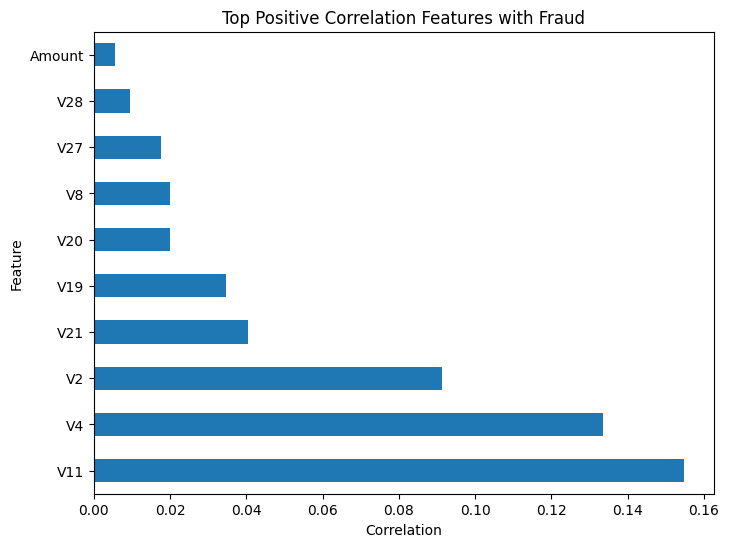

In [22]:
plt.figure(figsize=(8,6))
corr_target.drop("Class").head(10).plot(kind="barh")
plt.title("Top Positive Correlation Features with Fraud")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

In [23]:
df.to_csv("../data/processed/fraud_clean.csv", index=False)

print("fraud_clean.csv berhasil disimpan")

fraud_clean.csv berhasil disimpan
